# 01 — Telco Churn EDA

Quick exploratory pass over the **reference window** (`data/reference/reference_data.parquet`, first 60% of the cleaned data).

Goal: sanity-check nulls, class balance, feature types, and a couple of churn relationships before modelling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_parquet('../data/reference/reference_data.parquet')
print('shape:', df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


shape: (4225, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Structure, dtypes, nulls

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4225 non-null   object 
 1   SeniorCitizen     4225 non-null   int64  
 2   Partner           4225 non-null   object 
 3   Dependents        4225 non-null   object 
 4   tenure            4225 non-null   int64  
 5   PhoneService      4225 non-null   object 
 6   MultipleLines     4225 non-null   object 
 7   InternetService   4225 non-null   object 
 8   OnlineSecurity    4225 non-null   object 
 9   OnlineBackup      4225 non-null   object 
 10  DeviceProtection  4225 non-null   object 
 11  TechSupport       4225 non-null   object 
 12  StreamingTV       4225 non-null   object 
 13  StreamingMovies   4225 non-null   object 
 14  Contract          4225 non-null   object 
 15  PaperlessBilling  4225 non-null   object 
 16  PaymentMethod     4225 non-null   object 


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,4225,2,Male,2153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,4225.0,NaN,NaN,NaN,0.158817,0.365548,0.0,0.0,0.0,0.0,1.0
Partner,4225,2,No,2197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,4225,2,No,2961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,4225.0,NaN,NaN,NaN,32.158107,24.62953,0.0,8.0,28.0,55.0,72.0
PhoneService,4225,2,Yes,3831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,4225,3,No,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,4225,3,Fiber optic,1852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,4225,3,No,2100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,4225,3,No,1862,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Class balance

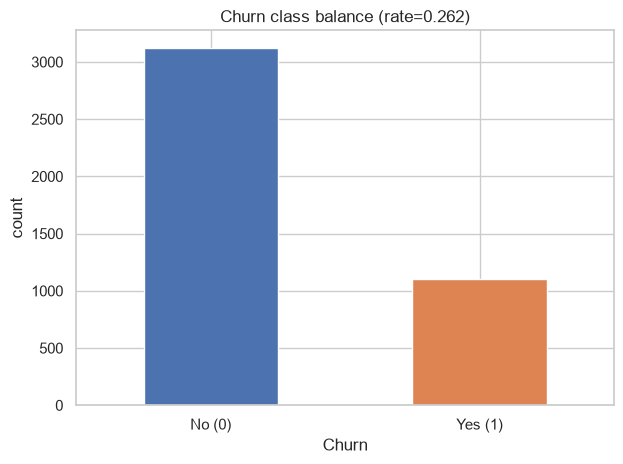

In [4]:
counts = df['Churn'].value_counts().sort_index()
ax = counts.plot(kind='bar', color=['#4c72b0', '#dd8452'])
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
ax.set_title(f'Churn class balance (rate={df["Churn"].mean():.3f})')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## Correlation — numerical features

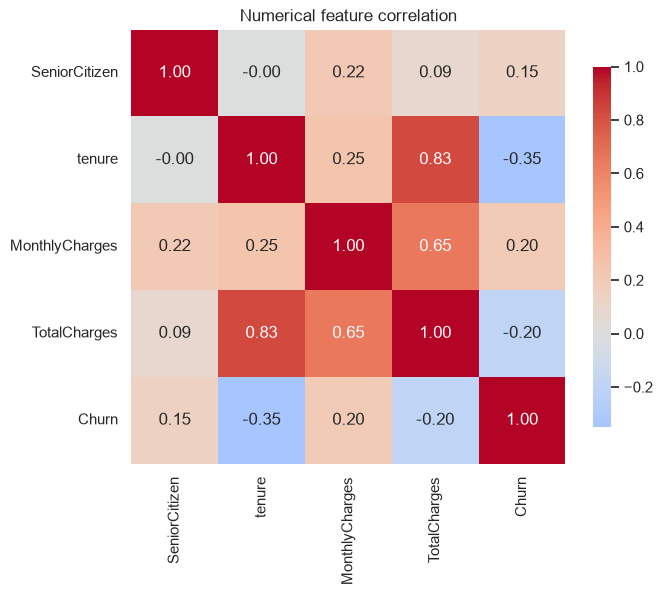

In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Numerical feature correlation')
plt.tight_layout()
plt.show()

## Churn rate by contract type

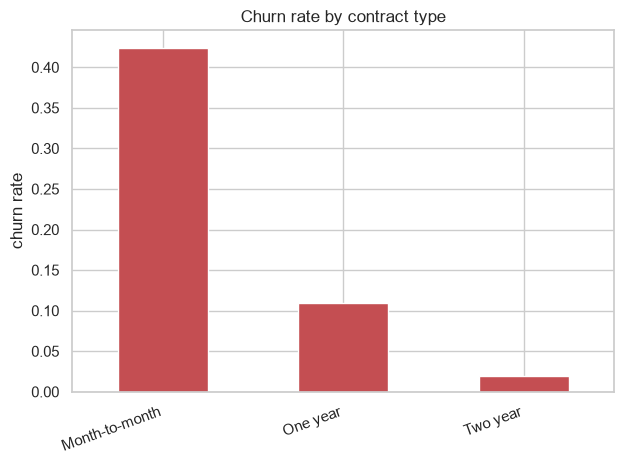

Contract
Month-to-month    0.424165
One year          0.109215
Two year          0.019763
Name: Churn, dtype: float64

In [6]:
rate = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
ax = rate.plot(kind='bar', color='#c44e52')
ax.set_title('Churn rate by contract type')
ax.set_ylabel('churn rate')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
rate